In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


In [ ]:
## load dataset
df = pd.read_csv('/content/athletes_data_set.csv') ## represents the athlete dataset
df2= pd.read_csv('/content/Medalist_data.csv') ## represents medalists dataset

In [ ]:
## preview
df.head()


,id,name,gender,born,died,height,weight,team,game,noc,sport,event,medal
0,131892,Meryem Erdoğan,Female,24 April 1990,NaN,172 cm,55 kg,Türkiye,2016 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
1,131892,Meryem Erdoğan,Female,24 April 1990,NaN,172 cm,55 kg,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
2,131892,Meryem Erdoğan,Female,24 April 1990,NaN,172 cm,55 kg,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
3,4300,Maurice Maina,Male,1 January 1963,NaN,158 cm,47 kg,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN
4,4300,Maurice Maina,Male,1 January 1963,NaN,158 cm,47 kg,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN


In [ ]:
## athlete dataset
#df=df.drop_duplicates(subset=['id','team','game','noc','sport','medal'],keep='first')
#df.head()
#df.shape

df = df.drop_duplicates(subset=['team', 'event', 'game', 'noc', 'medal'], keep='first')

# Display the cleaned data
df.head()
df.shape

(148189, 13)

In [ ]:
# medalist identify the duplicates keeping the first row based on mentioned subsets

df2=df2.drop_duplicates(subset=['Year','medal','noc','country','team','discipline','event','code_team'],keep='first')
df2.head()



,Year,medal,medal_code,name,gender,noc,country,Type,team,discipline,event,event_type,url_event,code_athlete,code_team,is_medallist
0,2024,Gold,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Summer Olympics,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903136,NaN,True
1,2024,Silver,2.0,GANNA Filippo,Male,ITA,Italy,Summer Olympics,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1923520,NaN,True
2,2024,Bronze,3.0,van AERT Wout,Male,BEL,Belgium,Summer Olympics,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903147,NaN,True
3,2024,Gold,1.0,BROWN Grace,Female,AUS,Australia,Summer Olympics,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1940173,NaN,True
4,2024,Silver,2.0,HENDERSON Anna,Female,GBR,Great Britain,Summer Olympics,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1912525,NaN,True


In [ ]:
df2.shape

(1044, 16)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
gender,0
born,1425
died,118932
height,30580
weight,32351
team,0
game,0
noc,0


In [ ]:
## dropping born ,died, height, weight colums as not needed in analysis.
columns_to_drop = ['born', 'died', 'height', 'weight']
for column in columns_to_drop:
    if column in df.columns:
        df = df.drop(columns=column)


In [ ]:
df.head()

,id,name,gender,team,game,noc,sport,event,medal
0,131892,Meryem Erdoğan,Female,Türkiye,2016 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
1,131892,Meryem Erdoğan,Female,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
3,4300,Maurice Maina,Male,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN
5,60239,Stanislav Tůma,Male,Czechoslovakia,1972 Summer Olympics,TCH,Wrestling,"Wrestling, Featherweight, Freestyle, Men(Olympic)",NaN
7,129369,Eunice Kirwa,Female,Bahrain,2016 Summer Olympics,BRN,Athletics,"Athletics, Marathon, Women(Olympic)",Silver


In [ ]:
## drop the empty columns from df2
df2.dropna(axis=1, how='all', inplace=True)
df2.head()

,Year,medal,medal_code,name,gender,noc,country,Type,team,discipline,event,event_type,url_event,code_athlete,code_team,is_medallist
0,2024,Gold,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Summer Olympics,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903136,NaN,True
1,2024,Silver,2.0,GANNA Filippo,Male,ITA,Italy,Summer Olympics,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1923520,NaN,True
2,2024,Bronze,3.0,van AERT Wout,Male,BEL,Belgium,Summer Olympics,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903147,NaN,True
3,2024,Gold,1.0,BROWN Grace,Female,AUS,Australia,Summer Olympics,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1940173,NaN,True
4,2024,Silver,2.0,HENDERSON Anna,Female,GBR,Great Britain,Summer Olympics,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1912525,NaN,True


In [ ]:
duplicate_rows = df[df.duplicated()]
number_of_duplicates = duplicate_rows.shape[0]
print(f"Number of duplicate rows: {number_of_duplicates}")

Number of duplicate rows: 0


In [ ]:
## as we are analysing 2 different types of olympic, summer and winter extracting the year and type of olympics from game column
df1 = df.copy()

## as we are analysing 2 different types of olympic, summer and winter extracting the year and type of olympics from game column
df1['Year'] = df1['game'].str.extract(R'(\d{4})').astype(int)
df1.head()

df1['Type'] = df1['game'].str.extract(R'(\D+)').astype(str)
df1.head()


,id,name,gender,team,game,noc,sport,event,medal,Year,Type
0,131892,Meryem Erdoğan,Female,Türkiye,2016 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN,2016,Summer Olympics
1,131892,Meryem Erdoğan,Female,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN,2020,Summer Olympics
3,4300,Maurice Maina,Male,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN,1988,Summer Olympics
5,60239,Stanislav Tůma,Male,Czechoslovakia,1972 Summer Olympics,TCH,Wrestling,"Wrestling, Featherweight, Freestyle, Men(Olympic)",NaN,1972,Summer Olympics
7,129369,Eunice Kirwa,Female,Bahrain,2016 Summer Olympics,BRN,Athletics,"Athletics, Marathon, Women(Olympic)",Silver,2016,Summer Olympics


In [ ]:
# for better representation of data moving Year column and make as first column

# inplace the changes done on this dataset
df1.insert(1, 'Year', df1.pop('Year'))

## also moving Type in between Year and name column
df1.insert(2, 'Type', df1.pop('Type'))
df1.head()

,id,Year,Type,name,gender,team,game,noc,sport,event,medal
0,131892,2016,Summer Olympics,Meryem Erdoğan,Female,Türkiye,2016 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
1,131892,2020,Summer Olympics,Meryem Erdoğan,Female,Türkiye,2020 Summer Olympics,TUR,Athletics,"Athletics, Marathon, Women(Olympic)",NaN
3,4300,1988,Summer Olympics,Maurice Maina,Male,Kenya,1988 Summer Olympics,KEN,Boxing,"Boxing, Light-Flyweight, Men(Olympic)",NaN
5,60239,1972,Summer Olympics,Stanislav Tůma,Male,Czechoslovakia,1972 Summer Olympics,TCH,Wrestling,"Wrestling, Featherweight, Freestyle, Men(Olympic)",NaN
7,129369,2016,Summer Olympics,Eunice Kirwa,Female,Bahrain,2016 Summer Olympics,BRN,Athletics,"Athletics, Marathon, Women(Olympic)",Silver


In [ ]:
# Combine the two DataFrames
new_df = pd.concat([df1, df2], ignore_index=True)

# Optionally, you might want to sort the data by a specific column (e.g., date)
new_df.sort_values(by='Year', inplace=True)

# Save the combined DataFrame to a new file
new_df.to_csv('combined_data.csv', index=False)

print("Data combined successfully!")


Data combined successfully!


In [ ]:
# remove duplicates if any in our combined dataset
new_df.drop_duplicates(subset=['noc','name','event','Year','sport','medal','medal_code','code_team'])
new_df.head()

,id,Year,Type,name,gender,team,game,noc,sport,event,medal,medal_code,country,discipline,event_type,url_event,code_athlete,code_team,is_medallist
101037,55911.0,1888,-,Sotirios Versis,Male,Greece,1888-89 Zappas Olympic Games,GRE,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Rope Climbin...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94588,15882.0,1896,Summer Olympics,Stamatios Nikolopoulos,Male,Greece,1896 Summer Olympics,GRE,Cycling Track (Cycling),"Cycling Track (Cycling), 333⅓ metres Time Tria...",Silver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63826,71333.0,1896,Summer Olympics,Dezső Wein,Male,Hungary,1896 Summer Olympics,HUN,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Parallel Bar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63827,71333.0,1896,Summer Olympics,Dezső Wein,Male,Hungary,1896 Summer Olympics,HUN,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Horizontal B...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63828,71333.0,1896,Summer Olympics,Dezső Wein,Male,Hungary,1896 Summer Olympics,HUN,Artistic Gymnastics (Gymnastics),"Artistic Gymnastics (Gymnastics), Rings, Men(O...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Filter data for the last 20 years (2004–2024)
new_df['Year'] = pd.to_numeric(new_df['Year'], errors='coerce')
new_df = new_df.dropna(subset=['Year'])
new_df['Year'] = new_df['Year'].astype(int)

new_df = new_df[(new_df['Year'] >= 2004) & (new_df['Year'] <= 2024)]
new_df


,id,Year,Type,name,gender,team,game,noc,sport,event,medal,medal_code,country,discipline,event_type,url_event,code_athlete,code_team,is_medallist
131597,43854.0,2004,Summer Olympics,Nasser Al-Attiya,Male,Qatar,2004 Summer Olympics,QAT,Shooting,"Shooting, Skeet, Men(Olympic)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
137772,105981.0,2004,Summer Olympics,Orsolya Nagy,Female,Hungary,2004 Summer Olympics,HUN,Fencing,"Fencing, Sabre, Individual, Women(Olympic)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32967,105727.0,2004,Summer Olympics,Radosław Popławski,Male,Poland,2004 Summer Olympics,POL,Athletics,"Athletics, 3,000 metres Steeplechase, Men(Olym...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58337,103477.0,2004,Summer Olympics,Brittany Reimer,Female,Canada,2004 Summer Olympics,CAN,Swimming (Aquatics),"Swimming (Aquatics), 400 metres Freestyle, Wom...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58336,103477.0,2004,Summer Olympics,Brittany Reimer,Female,Canada,2004 Summer Olympics,CAN,Swimming (Aquatics),"Swimming (Aquatics), 200 metres Freestyle, Wom...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148541,NaN,2024,Summer Olympics,ZHANG Yufei,Female,NaN,NaN,CHN,NaN,Women's 50m Freestyle,Bronze,3.0,China,Swimming,ATH,/en/paris-2024/results/swimming/women-s-50m-fr...,1945125.0,NaN,True
148542,NaN,2024,Summer Olympics,FAN Zhendong,Male,NaN,NaN,CHN,NaN,Men's Singles,Gold,1.0,China,Table Tennis,HATH,/en/paris-2024/results/table-tennis/men-s-sing...,1902295.0,NaN,True
148543,NaN,2024,Summer Olympics,MOREGARD Truls,Male,NaN,NaN,SWE,NaN,Men's Singles,Silver,2.0,Sweden,Table Tennis,HATH,/en/paris-2024/results/table-tennis/men-s-sing...,1563390.0,NaN,True
148545,NaN,2024,Summer Olympics,DJOKOVIC Novak,Male,NaN,NaN,SRB,NaN,Men's Singles,Gold,1.0,Serbia,Tennis,HATH,/en/paris-2024/results/tennis/men-s-singles/fn...,1956398.0,NaN,True


In [ ]:
# Remove leading and trailing spaces in the 'Type' column
new_df['Type'] = new_df['Type'].str.strip()
new_df['Type'].unique()

array(['Summer Olympics', 'Winter Olympics', 'Summer Youth Olympics',
       'Winter Youth Olympics'], dtype=object)

In [ ]:
## separating summer and winter olympics
summer_olympics = new_df[new_df['Type'] == 'Summer Olympics']
print("Summer Olympics Data:")
print(summer_olympics.head())


winter_olympics = new_df[new_df['Type'] == 'Winter Olympics']
print("Winter Olympics Data:")
print(winter_olympics.head())


Summer Olympics Data:
              id  Year             Type                name  gender     team  \
131597   43854.0  2004  Summer Olympics    Nasser Al-Attiya    Male    Qatar   
137772  105981.0  2004  Summer Olympics        Orsolya Nagy  Female  Hungary   
32967   105727.0  2004  Summer Olympics  Radosław Popławski    Male   Poland   
58337   103477.0  2004  Summer Olympics     Brittany Reimer  Female   Canada   
58336   103477.0  2004  Summer Olympics     Brittany Reimer  Female   Canada   

                        game  noc                sport  \
131597  2004 Summer Olympics  QAT             Shooting   
137772  2004 Summer Olympics  HUN              Fencing   
32967   2004 Summer Olympics  POL            Athletics   
58337   2004 Summer Olympics  CAN  Swimming (Aquatics)   
58336   2004 Summer Olympics  CAN  Swimming (Aquatics)   

                                                    event medal  medal_code  \
131597                      Shooting, Skeet, Men(Olympic)   NaN      

In [ ]:
new_df['Type'].unique()

array(['Summer Olympics', 'Winter Olympics', 'Summer Youth Olympics',
       'Winter Youth Olympics'], dtype=object)

In [ ]:
## Analysing medals counts by country.
# first for the summer olympics.
summer_olympics = summer_olympics.copy()  # Create a deep copy
summer_olympics.loc[summer_olympics['noc'] == 'ROC', 'noc'] = 'RUS'
summer_medal_counts = summer_olympics.groupby('noc')['medal'].count().reset_index().sort_values(by='medal', ascending=False)
summer_medal_counts.head()

,noc,medal
202,USA,679
40,CHN,505
162,RUS,396
71,GBR,343
12,AUS,260


In [ ]:
# first for the winter olympics.

winter_medal_counts =winter_olympics.groupby('noc')['medal'].count().reset_index().sort_values(by='medal', ascending=False)
winter_medal_counts.head()

,noc,medal
78,NOR,146
37,GER,140
110,USA,138
16,CAN,135
7,AUT,88


In [ ]:
## As per our guiding question display top 10 countries for summer and winter

print("Top 10n countries for Summer Olympics:")
print(summer_medal_counts.head(10))

print("\nTop 10n countries for Winter Olympics:")
print(winter_medal_counts.head(10))

Top 10n countries for Summer Olympics:
     noc  medal
202  USA    679
40   CHN    505
162  RUS    396
71   GBR    343
12   AUS    260
67   FRA    251
75   GER    250
100  JPN    244
96   ITA    199
105  KOR    165

Top 10n countries for Winter Olympics:
     noc  medal
78   NOR    146
37   GER    140
110  USA    138
16   CAN    135
7    AUT     88
75   NED     78
91   RUS     75
100  SWE     73
34   FRA     64
98   SUI     64


In [ ]:
# colur coding for ecah country
# Unique country codes and corresponding colors
unique_country_code = df['noc'].unique()
color_code = [
    "#FF6633", "#FFB399", "#FF33FF", "#FFFF99", "#00B3E6",
    "#E6B333", "#3366E6", "#999966", "#99FF99", "#B34D4D",
    "#80B300", "#809900", "#E6B3B3", "#6680B3", "#66991A",
    "#FF99E6", "#CCFF1A", "#FF1A66", "#E6331A", "#33FFCC",
    "#66994D", "#B366CC", "#4D8000", "#B33300", "#CC80CC",
    "#66664D", "#991AFF", "#E666FF", "#4DB3FF", "#1AB399",
    "#E666B3", "#33991A", "#CC9999", "#B3B31A", "#00E680",
    "#4D8066", "#809980", "#E6FF80", "#1AFF33", "#999933",
    "#FF3380", "#CCCC00", "#66E64D", "#4D80CC", "#9900B3",
    "#E64D66", "#4DB380", "#FF4D4D", "#99E6E6", "#6666FF",
    "#003366", "#663399", "#FF6666", "#66CCFF", "#669999",
    "#FF9966", "#66FF33", "#CC3333", "#FFCC00", "#336666",
    "#33CCCC", "#99CC33", "#FF66CC", "#99CCCC", "#996699",
    "#FF99CC", "#CCCC99", "#9999CC", "#33CC66", "#FF6666",
    "#3366FF", "#9999FF", "#666633", "#CC9966", "#663333",
    "#3399FF", "#FF9966", "#FF6699", "#33FF99", "#6699FF",
    "#9966FF", "#FF9966", "#669933", "#99FF66", "#33FFCC",
    "#9933FF", "#99FFCC", "#33CCFF", "#9966CC", "#FF9933",
    "#66FF99", "#FFCC99", "#99CCFF", "#996633"
]

# Map the country codes to colors
#color_dict = {code: color_code[i] for i, code in enumerate(unique_country_code)}
color_dict = {code: color_code[i % len(color_code)] for i, code in enumerate(unique_country_code)}
# Assign colors to the dataframe based on country codes
df['color'] = df['noc'].map(color_dict)


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

FileNotFoundError: [Errno 2] No such file or directory: '/content/summerlogo.png'

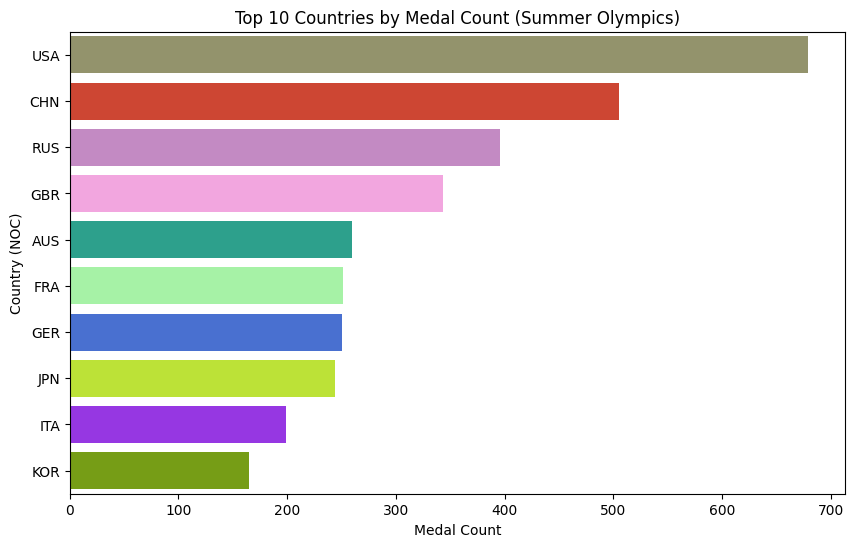

In [ ]:
## let's visualize this

# Plot for Summer Olympics

# Plot with custom colors for countries
plt.figure(figsize=(10, 6))

# Get the top 10 countries
top_10_countries = summer_medal_counts.head(10)

#Extract colors for the top 10 countries from the color dictionary
colors = [color_dict[country] for country in top_10_countries['noc']]

sns.barplot(x='medal', y='noc', data=top_10_countries, hue='noc', palette=colors, legend=False)

plt.title('Top 10 Countries by Medal Count (Summer Olympics)')
plt.xlabel('Medal Count')
plt.ylabel('Country (NOC)')

# Load and place the image
img = mpimg.imread('/content/summerlogo.png')  # Replace with correct path to your image
imagebox = OffsetImage(img, zoom=0.3)
ab = AnnotationBbox(imagebox, (500, 6), xycoords='data', frameon=False)
ax = plt.gca()
ax.add_artist(ab)

plt.tight_layout()
plt.show()



/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

FileNotFoundError: [Errno 2] No such file or directory: '/content/winterlogo.jpg'

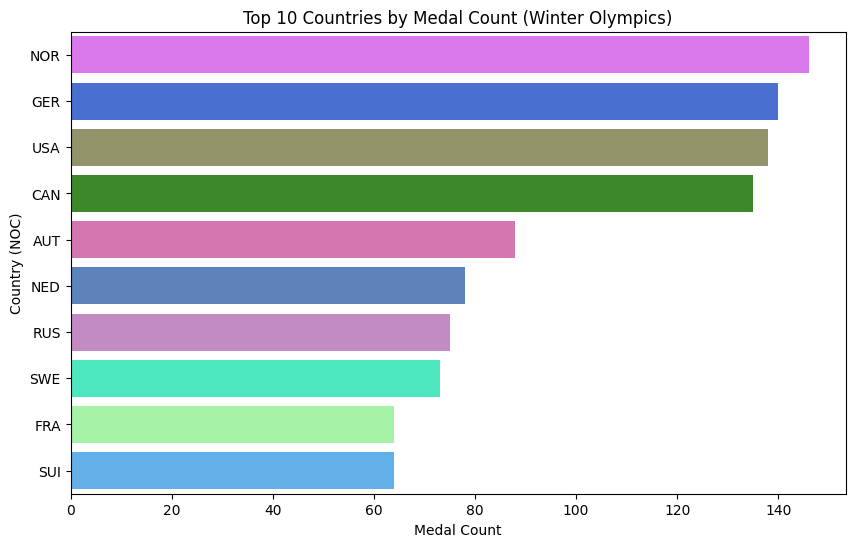

In [ ]:
## plot for the winter top 10 medalist countries

# Plot with custom colors for countries
plt.figure(figsize=(10, 6))
sns.barplot(x='medal', y='noc', data=winter_medal_counts.head(10), palette=[color_dict[code] for code in winter_medal_counts.head(10)['noc']], hue='noc', legend=False)
plt.title('Top 10 Countries by Medal Count (Winter Olympics)')
plt.xlabel('Medal Count')
plt.ylabel('Country (NOC)')

img2 = mpimg.imread('/content/winterlogo.jpg')

# Create the image object and place it on the bar chart
imagebox = OffsetImage(img2, zoom=0.1)
ab2 = AnnotationBbox(imagebox, (110, 6), xycoords='data', frameon=False)
ax2 = plt.gca()
# Add the image to the plot
ax2.add_artist(ab2)

plt.show()




---


** Analyze Medal Distribution Over Time **

---



In [ ]:
# Group medal counts by country and year for both Summer and Winter

summer_trends = summer_olympics.groupby(['Year', 'noc'])['medal'].count().reset_index()
winter_trends = winter_olympics.groupby(['Year', 'noc'])['medal'].count().reset_index()


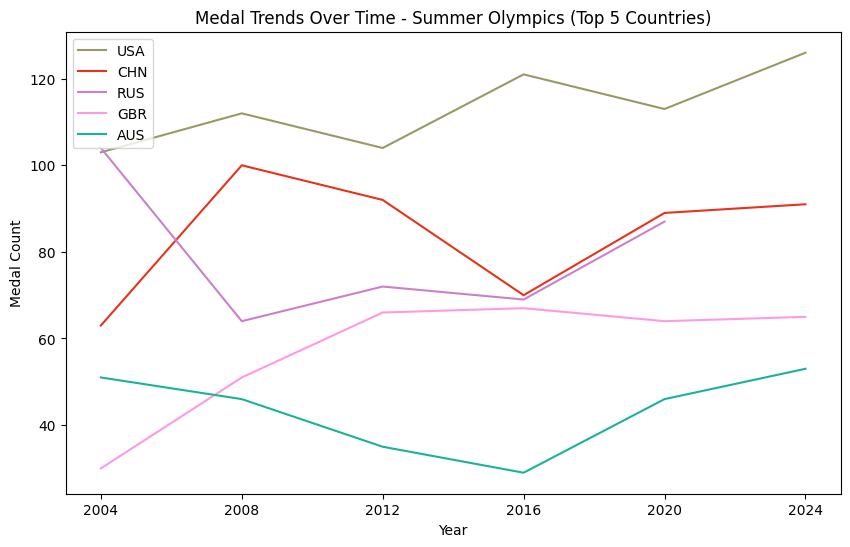

In [ ]:
# Plot medal trends over time for the top 5 Summer countries

top_5_summer = summer_medal_counts.head(5)['noc'].tolist()
plt.figure(figsize=(10, 6))

for country in top_5_summer:
    country_data = summer_trends[summer_trends['noc'] == country]
    plt.plot(country_data['Year'], country_data['medal'], label=country, color=color_dict[country])

plt.title('Medal Trends Over Time - Summer Olympics (Top 5 Countries)')
plt.xlabel('Year')
plt.ylabel('Medal Count')
plt.xticks(summer_trends['Year'].unique())
plt.legend()
plt.show()


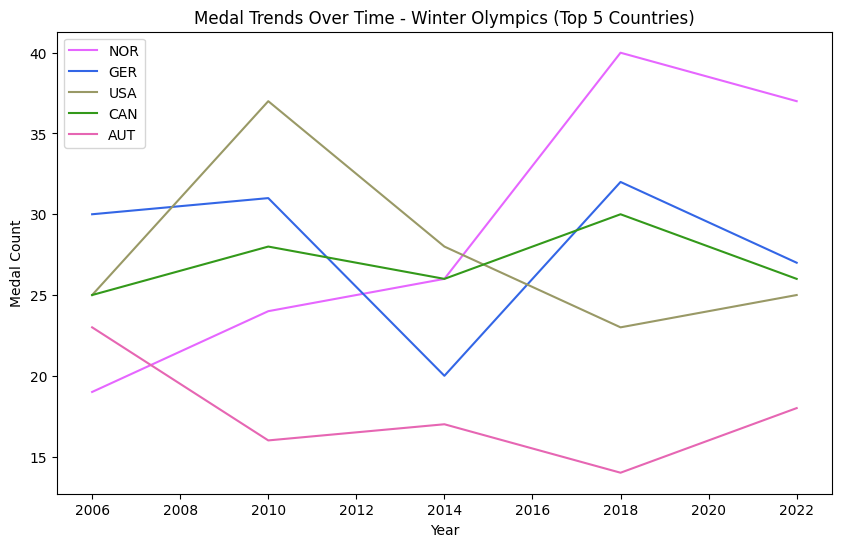

In [ ]:
# Plot medal trends over time for the top 5 Winter countries
top_5_winter = winter_medal_counts.head(5)['noc'].tolist()
plt.figure(figsize=(10, 6))
for country in top_5_winter:
    country_data = winter_trends[winter_trends['noc'] == country]
    plt.plot(country_data['Year'], country_data['medal'], label=country, color=color_dict[country])

plt.title('Medal Trends Over Time - Winter Olympics (Top 5 Countries)')
plt.xlabel('Year')
plt.ylabel('Medal Count')
plt.legend()
plt.show()
